<a href="https://colab.research.google.com/github/mlylp/AI_Oracle_Next_Education/blob/main/Search-Agents-LangGraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# O % no %pip install garante que a instalação do pacote aconteça no mesmo ambiente Python que o notebook está usando de fato. Importante principalmente quando roda Jupyter local.

# LangChain: framework com as peças básicas (prompts, modelos, parsers, ferramentas)
# LangGraph: extensão do LangChain, que organiza essas peças em forma de grafo, permitindo decisões e repetições

%pip uninstall -y google-ai-generativelanguage google-generativeai langchain-google-genai
%pip install google-ai-generativelanguage==0.6.15
%pip install -U langchain-google-genai
%pip install -U langchain
%pip install -U langchain-pinecone
%pip install -U langchain-community
%pip install -U langgraph
%pip install arxiv
%pip install -U langchain-tavily

Found existing installation: google-ai-generativelanguage 0.6.15
Uninstalling google-ai-generativelanguage-0.6.15:
  Successfully uninstalled google-ai-generativelanguage-0.6.15
Found existing installation: langchain-google-genai 4.2.7
Uninstalling langchain-google-genai-4.2.7:
  Successfully uninstalled langchain-google-genai-4.2.7
  Using cached google_ai_generativelanguage-0.6.15-py3-none-any.whl.metadata (5.7 kB)
Using cached google_ai_generativelanguage-0.6.15-py3-none-any.whl (1.3 MB)


  Using cached langchain_google_genai-4.2.7-py3-none-any.whl.metadata (2.7 kB)
Using cached langchain_google_genai-4.2.7-py3-none-any.whl (70 kB)
  Using cached langchain_community-0.4.2-py3-none-any.whl.metadata (3.4 kB)
  Using cached httpx_sse-0.4.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached langchain_classic-1.0.8-py3-none-any.whl.metadata (5.1 kB)
  Using cached pydantic_settings-2.14.2-py3-none-any.whl.metadata (3.4 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached langchain_text_splitters-1.1.2-py3-none-any.whl.metadata (3.3 kB)
Using cached langchain_community-0.4.2-py3-none-any.whl (2.4 MB)
Using cached httpx_sse-0.4.3-py3-none-any.whl (9.0 kB)
Using cached langchain_classic-1.0.8-py3-none-any.whl (1.0 MB)
Using cached pydantic_settings-2.14.2-py3-none-any.whl (61 kB)
Using cached requests-2.34.2-py3-none-any.whl (73 kB)
Using cached langchain_text_splitters-1.1.2-py3-none-any.whl (35 kB)
  Attempting uninstall: requests
    Found exis

In [1]:
# protege os dados da API dentro do Google Colab

from google.colab import userdata
api_key = userdata.get('gemini-API')

# O módulo os permite que o Python converse com o sistema operacional.
# Aqui ele é usado para criar variáveis de ambiente,
# que são valores que ficam disponíveis para qualquer parte do programa,
# sem precisar passar a chave manualmente toda hora.

import os

# A biblioteca LangGraph, para se conectar ao modelo,
# procura automaticamente por uma variável de ambiente chamada GOOGLE_API_KEY

os.environ['GOOGLE_API_KEY'] = api_key

In [3]:
# langchain_google_genai é um pacote separado que faz a ponte entre o LangChain/LangGraph e os modelos do Google
# ChatGoogleGenerativeAI é uma classe que representa o modelo de chat do Gemini dentro do ecossistema LangChain

from langchain_google_genai import ChatGoogleGenerativeAI

In [4]:
llm = ChatGoogleGenerativeAI(model = 'gemini-3.1-flash-lite')

In [5]:
# a classe PromptTemplate serve para criar prompts dinâmicos,
# com partes que mudam de acordo com a entrada do usuário.

from langchain_core.prompts import PromptTemplate

modelo_de_prompt = PromptTemplate(
    template = "Me diga quais os impactos da IA no assunto {assunto}",
    input_variables = ["assunto"]
)

In [6]:
# Ao chamar um llm pelo LangChain, a resposta vem dentro de um objeto
# que carrega a resposta junto com metadados extras (com tokens usados, e etc...)
# StrOutputParser pega a saída do modelo e devolve apenas o conteúdo de texto, como uma string simples

from langchain_core.output_parsers import StrOutputParser

In [7]:
# | = "o que sai daqui entra ali".
# entrada do usuário → [modelo_de_prompt] → [llm] → [StrOutputParser] → resultado final

cadeia = modelo_de_prompt | llm | StrOutputParser()

In [ ]:
resposta = cadeia.invoke({'assunto': 'Agricultura'})

In [ ]:
print(resposta)

A Inteligência Artificial (IA) está revolucionando o setor agrícola, impulsionando o que hoje chamamos de **Agricultura 4.0** (e já caminhando para a 5.0). A fusão de dados, algoritmos de aprendizado de máquina (*machine learning*), sensores e robótica está mudando a forma como os alimentos são cultivados, colhidos e distribuídos.

Abaixo, divido os principais impactos da IA na agricultura em **impactos positivos (benefícios)**, **tecnologias práticas** e os **desafios** dessa transição.

---

### 1. Impactos Positivos e Benefícios

#### A. Aumento da Produtividade e Eficiência
A IA permite o manejo de precisão. Em vez de tratar uma lavoura inteira da mesma forma, o agricultor pode tratar cada metro quadrado (ou até cada planta) individualmente.
* **Previsão de safra:** Algoritmos analisam dados históricos, clima e condições do solo para prever o rendimento das colheitas com alta precisão.
* **Detecção precoce de pragas e doenças:** Sistemas de visão computacional analisam imagens de d

In [8]:
# O Tavily é um serviço de busca feito especificamente para ser usado por agentes de IA
# TavilySearchResults é a classe que embrulha essa API de busca no formato que o LangChain espera
# Tool é a classe genérica que representa qualquer "ferramenta" que um agente pode usar.
# Age como um contrato, uma estrutura padrão que qualquer função (busca na internet, calculadora, consulta a banco de dados, etc.) precisa seguir para que o agente saiba como chamá-la.
from langchain_tavily import TavilySearch
from langchain_core.tools import tool

In [9]:
os.environ['TAVILY_API_KEY'] = userdata.get('tavily-API')

In [10]:
# tool é um decorador vem do LangChain e transforma essa função Python comum numa ferramenta
# que o agente consegue reconhecer e chamar sozinho

@tool
def busca_web(query: str) -> list:
  """
  Busca na web por um termo específico
  """

  tavily_search = TavilySearch(max_results = 2, search_depth = 'advanced', max_tokens = 1000)
  resultado_busca = tavily_search.invoke(query)
  return resultado_busca


In [ ]:
busca_web.invoke('IA na agricultura')

{'query': 'IA na agricultura',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://rehagro.com.br/blog/inteligencia-artificial-no-agronegocio',
   'title': 'Inteligência artificial no agronegócio: quais seus usos e desafios?',
   'content': 'Além dos desafios técnicos, existem preocupações relacionadas à privacidade e segurança dos dados agrícolas. A IA na agricultura envolve a coleta e processamento de informações sensíveis, como dados climáticos, geoespaciais e de produção. É essencial estabelecer regulamentações e mecanismos de proteção de dados que garantam a confidencialidade e o uso ético das informações coletadas, evitando abusos ou acesso indevido. [...] Uma das principais aplicações da IA no agronegócio é a análise de dados agrícolas em larga escala com o uso de:\n\n Sensores;\n Drones;\n Imagens de satélite e outros dispositivos.\n\nÉ possível coletar uma enorme quantidade de informações sobre o clima, a qualidade do solo, o crescimento

In [11]:
# lista Python contendo as ferramentas que o agente vai poder usar.
tools = [busca_web]

In [12]:
#.bind() cria uma cópia configurada do modelo llm, com alguns parâmetros fixos "grudados" nela, sem precisar passar esses parâmetros toda vez que chamar o modelo.
# Na prática, a lista de ferramentas passada em tools é enviada junto de cada requisição para a API do Gemini.
# É a própria API do Gemini que recebe "aqui estão as ferramentas disponíveis" e decide, sozinha, se a pergunta do usuário exige usar alguma delas ou não.
llm_com_ferramenta = llm.bind(tools = tools)

In [13]:
modelo_de_prompt = PromptTemplate(
    template = "Usando apenas as tools disponíveis, me diga quais os impactos da IA no assunto {assunto}",
    input_variables = ["assunto"]
)

In [14]:
cadeia = modelo_de_prompt | llm_com_ferramenta | StrOutputParser()

In [ ]:
resposta = cadeia.invoke({'assunto': 'Agricultura'})
resposta

''

In [15]:
prompt = """
  Usando apenas as tools disponíves, me diga quais os impactos da IA no assunto Agricultura
  """

In [ ]:
resposta = llm_com_ferramenta.invoke(prompt)
print(resposta)

content=[] additional_kwargs={'function_call': {'name': 'busca_web', 'arguments': '{"query": "impactos da inteligencia artificial na agricultura"}'}, '__gemini_function_call_thought_signatures__': {'c9ph1nn8': 'EqkECqYEARFNMg9XNMMpSnrfpfAbF2eTJVUjQPDQj4BDRi5z9I/e41iCP/dWd2ulZYLA7zKtzmoFL021DFmMvm/BzHy5/uo3al5vrsB85mgCtNQjZ8Z5Q6i3CBErZnrS5Y+Klr2OPZ506FU5LZbTtrtXQCUB56JD5GN1DFBWfTe2sxPpZXhIne+zdbwA2e0RVQPgIfu+ofgD9OIzKvlpfS6jmoFPc0Sh8bYgL3achDJIFN4GI62Q17/npI0GzG59znB1xb2SBQKdMU+HBQJQeHD0sxl3cFeTdLk2bLgmbwxnNUJXoFpZcT4PbAXQa8BggPli2842H+PzLSWI2NpUz598nPmupROemtfz9/x8VbRoC7YldcUpegyldK9z9q3L/vCS+exgBIV+/3B3FVO63vMGypvWjeMUDg2essUdvUJ6ObTm0AesqY/AM9o4UA94mpVO1Pkw8k8rX6+1JU+IQh/fT9/gLfnNlV26tNe1x+2xVZx3MhUs5he0NEvL0K5/WWYbbvNvcGG+bVc6iDna6LawJC4Rh5lkkx+hZuVtq230l/Y/ZuXJnyR2PhASHmCVppPN+AkKZhFSubzf2WsX8QOhD5AynIQrT7TltwW/3HBjscfcVSk4rABpZQXHbgJMYxc9knKJXQUPUpVKyeNjOKGSt1zp0x4j/rAsM2yjOHj8MjafjrQMD6Y2w5HDay9DESgi1+VkbXOowAy3c3W0DAs9unGLQFdFZYZmVQ=='}} response_metadata={'finish_reason': 'STOP

In [16]:
# create_react_agent é uma função pronta do LangGraph que monta um agente completo, sem precisar construir o grafo manualmente

from langgraph.prebuilt import create_react_agent

In [17]:
system_prompt = """ Atue como um assistente útil.
Use as ferramentas fornecidas para responder às perguntas do usuário.
- busca_web: Retorna os resultados de uma busca na web.
Use a busca_web sempre que o usuário fizer uma pergunta sobre um tema específico e retorne o link dos artigos
"""

In [18]:
# ReAct é um padrão de raciocínio (vem de "Reasoning + Acting"). Funciona em ciclo:
# O modelo raciocina: "para responder isso, preciso buscar informação atualizada"
# O modelo age: chama a ferramenta busca_web
# O resultado da busca volta pro modelo
# O modelo raciocina de novo: "agora tenho informação suficiente para responder" (ou decide buscar mais)
# Repete até ter uma resposta final

# Detalhes sobre agente langGraph: https://docs.langchain.com/oss/python/langchain/agents#structured-output
agente_web = create_react_agent(model = llm, tools = tools, prompt = system_prompt )

/tmp/ipykernel_3043/2181063268.py:9: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agente_web = create_react_agent(model = llm, tools = tools, prompt = system_prompt )


In [68]:
# Formato de entrada: um dicionário com a chave "messages", contendo uma lista de tuplas.
# Cada tupla representa uma mensagem no formato (papel, conteúdo)
# (existem outros papéis possíveis, como "assistant" ou "system")

resultado = agente_web.invoke({"messages": [("user", "Quais os impactos da IA na agricultura")]})

In [ ]:
# Formato de saída: um dicionário. Dentro dele, resultado['messages'] é a lista completa da conversa, incluindo:
# A mensagem original do usuário
# Possivelmente uma mensagem do modelo decidindo chamar a ferramenta
# O resultado da ferramenta busca_web
# A resposta final do modelo, já usando essa informação

resultado

{'messages': [HumanMessage(content='Quais os impactos da IA na agricultura', additional_kwargs={}, response_metadata={}, id='fe92d010-b5b1-4e33-bdfe-b3ba5690f312'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'busca_web', 'arguments': '{"query": "impactos da inteligencia artificial na agricultura beneficio artigos"}'}, '__gemini_function_call_thought_signatures__': {'f5hqj4jv': 'EqUGCqIGARFNMg9vS3N8zD/TlmNcKMn7vvzDYO2vfnB+ZVRaFFJZVfXz5ZkAziCE7ShWfLNB+CbMPxB1rD03QSvuBR4uUbk5invKLZXedLEoDquL1jzncqokAO5cfy/IArcputMbNRcsQOILlS3dgFPrRrF/QFzAw8CChH4LdRyTbH7phwY/CuIS+rWFx+H8b4Qhv1bWd+VTMLnrJ0cjHOTM4cAiJiPtJbP5DKyHvAKX1O2dg8IgFSj8+bzlE/MMcmln4BBXGb+nxpXJhvqfkSIE3Jvjpr9kbCdtqj0J/orSCpJonB8WUjoPxZBaSlCUl84VUxF4epE7PKrOVHVRWezdPu2pfU9kOgMmOjug5sm8JScKb3CE4Wnra/QMhlIOCjMiyfMbvTRNiIRm03OFGxh7ZFcLKyWbuydw/65s7NGCqG1Fv3xwYm+vbMZP/m+c/EVtTOZmE4Hp9i6ktSqHq3H4CSgjK25BRKVr8QY7dTdSsiS5RX502xRm0OzfWPPCc/D8rfvt8LpjDXMQWHhggnOG3IzJ/O4aVbSS4Xv6a1I/mx11pcjYJH6D1ay5fAV0hc8dIXB7zvO6d4s7N

In [ ]:
# O [-1] pega o último item dessa lista, ou seja, a resposta final do agente, depois de todo o ciclo ReAct ter acontecido
resultado['messages'][-1]

AIMessage(content=[{'type': 'text', 'text': 'A integração da Inteligência Artificial (IA) no agronegócio tem gerado uma verdadeira revolução digital (muitas vezes associada à **Agricultura 4.0** e caminhando para a **Agricultura 6.0**). Essa tecnologia afeta positivamente a produtividade, a sustentabilidade e a eficiência operacional, embora também traga desafios estruturais importantes.\n\nAbaixo estão descritos os principais impactos da IA na agricultura:\n\n### 1. Aumento da Produtividade e Eficiência Operacional\nA IA permite automatizar processos e tomar decisões muito mais rápidas e precisas do que a capacidade humana isolada.\n* **Maquinários autônomos e drones:** Tratores que operam de forma autônoma e drones equipados com IA conseguem mapear plantações, aplicar defensivos agrícolas de forma cirúrgica e monitorar a saúde da lavoura em tempo real.\n* **Decisões baseadas em dados:** Sistemas baseados em *machine learning* (aprendizado de máquina) analisam grandes volumes de dados

In [20]:
import arxiv
from langchain_core.tools import tool

@tool
def busca_arxiv(query: str) -> str:
  """
  Busca artigos científicos no Arxiv por um termo específico e retorna os títulos e links dos artigos.
  """
  client = arxiv.Client()
  search = arxiv.Search(
      query = query,
      max_results = 5, # limit to 5 results for brevity
      sort_by = arxiv.SortCriterion.Relevance,
      sort_order = arxiv.SortOrder.Descending
  )
  results = client.results(search)
  formatted_results = []
  for i, result in enumerate(results):
      formatted_results.append(f"{i+1}. Título: {result.title}\n   Link: {result.pdf_url}")
  if not formatted_results:
      return "Nenhum artigo encontrado no Arxiv para esta busca."
  return "\n".join(formatted_results)

tool_cientifica = [busca_arxiv]

In [21]:
system_prompt2 = """
Atue como um assistente útil.
Use as ferramentas fornecidas para responder às perguntas do usuário.
- arxiv_tool: Retorna os resultados de uma busca no arxiv.
Use a arxiv_tool sempre que o usuário fizer uma pergunta sobre um tema específico e retorne o título dos artigos na resposta
"""

In [22]:
agente_cientifico = create_react_agent(model=llm, tools=tool_cientifica, prompt = system_prompt2)

/tmp/ipykernel_3043/3378028426.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agente_cientifico = create_react_agent(model=llm, tools=tool_cientifica, prompt = system_prompt2)


In [ ]:
resultado = agente_cientifico.invoke({"messages": [("user", "AI impact in agriculture")]})

In [ ]:
resultado

{'messages': [HumanMessage(content='AI impact in agriculture', additional_kwargs={}, response_metadata={}, id='fa5e83d0-8bf6-4176-b0a2-670932d9ac05'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'busca_arxiv', 'arguments': '{"query": "AI impact in agriculture"}'}, '__gemini_function_call_thought_signatures__': {'beobvfkw': 'Eu0HCuoHARFNMg9tRuMM9JXmA/bLvaudR0YtJXMK5O3qnjhJnbREMdTHgVAt3ixXPHl/Qxh1MC3ssc0RWqBeASS6+COVcrhAj2kob8dpGqmWbrmIUpbJmwNYzcgCOis+xxsjuDxKU1weH2/D2zcCVvvA1veuJVBiO9cwomQXjezJ+hT3hsFX7xTzR2a704nNemWGCxa9FH1lX4CPVwkAEet1Rji6FSDYEKauZ4V6yUJhhAv8PnvMOavgGIQZIgobHkTJb/Z6rd75UPtnTzT89V5YOpADAyU1Ihcutm4X3WEmbOVVOwq5F0CgLy2gGJIeoSmLfQfCnVbwKswE+FDRn8vZOaEQDjJ+Dq1UpIxghVWnjRQ0UYEWO/jQaW9T/GvgDYq4E636mKrEzO1Exa2vvipY4kTFFFG5oEOPWia1bhm98GPdDlFZ5u3jS+ylvUp8XnvsQ598h0wG9fUgr8mSV7xmrcFQ5e0uL8mwnHUR1jhmV586YPd5Gz1dI7lpswtCP0q6nDX6WomBC7Yxu/Bg7gYvIg7bPRE1LgwzAZuXZTEhuagdlCHLsdWNo7FJV1t9ABBN1ydZbkjyj4+W5zD20VRlgOebX4uo7ILyLkIJxqtHPmuFnSl5tMZ86VNqhIjkN7dPigvrJ

In [52]:
# Garante que o conteúdo retornado seja sempre string, mesmo se vier como lista de blocos (resultado dos modelos de llm mais novos do gemini)
def extrair_texto(content):
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        partes = []
        for item in content:
            if isinstance(item, dict) and "text" in item:
                partes.append(item["text"])
            elif isinstance(item, str):
                partes.append(item)
        return "\n".join(partes)
    return str(content)

In [23]:
# TypedDict vem do módulo typing do próprio Python.
# Ele serve para criar um tipo de dicionário com estrutura fixa: você define de antemão quais chaves ele deve ter e qual o tipo de cada valor.
# Isso ajuda ferramentas como o LangGraph a validar os campos


from typing import TypedDict

In [24]:
# AgentState é um "pacote de informação" que percorre o grafo gerado no langGraph
class AgentState(TypedDict):
  user_query: str
  web_answer: str
  scientific_answer: str
  final_answer: str

In [53]:
# Esse bloco é a implementação completa do nó "agente científico" dentro do fluxo do LangGraph
# recebe o state (o pacote de dados do grafo) e retorna um dict

def funcao_agente_cientifico(state: AgentState) -> dict:
  """
  Função que executa um agente no estilo ReAct que realiza uma busca no arxiv por um termo específico.

  Esta função pega o estado atual do agente (que contém a pergunta do usuário) e cria
  um agente usando o Gemini e a ferramenta arxiv e retorna a resposta do agente.

  Args:
      state: (AgentState): Um dicionário contendo a pergunta do usuário e a resposta do agente.

  Returns:
      str: a resposta do agente.
  """

#  instrução geral que orienta o comportamento do agente

  system_prompt = """ Atue como um assistente útil.
  Use as ferramentas fornecidas para responder às perguntas ao usuário.
  - tool_cientifica = Retorna os resultados de uma busca no arxiv.
  Use a tool_cientifica sempre que o usuário fizer uma pergunta sobre um tema específico e retorne o título dos artigos na resposta
  """
# cria o agente, invoca ele passando a pergunta do usuário (que vem de dentro do state, puxando a chave 'user_query'), e extrai o texto final da resposta com .content
  agente_cientifico = create_react_agent(model=llm, tools=tool_cientifica, prompt = system_prompt)
  resultado = agente_cientifico.invoke({"messages": [("user", state['user_query'])]})
  resposta_final = extrair_texto(resultado['messages'][-1].content)
# scientific_answer precisa ser apresentado entre aspas por ser uma chave de dicionário
  return {"scientific_answer": resposta_final}

In [54]:
# Os agentes serão transformados em funções para que virem nós dentro do langGraph
def funcao_agente_web(state: AgentState) -> dict:
  """
  Função que executa um agente no estilo ReAct que realiza uma busca na web por um termo específico.

  Esta função pega o estado atual do agente (que contém a pergunta do usuário) e cria
  um agente usando o Gemini e a ferramenta tavily e retorna a resposta do agente.

  Args:
    state: (AgentState): Um dicionário contendo a pergunta do usuário e a resposta do agente.

  Returns:
    str: a resposta do agente.
  """

  system_prompt = """ Atue como um assistente útil.
    Use as ferramentas fornecidas para responder às perguntas do usuário.
    - busca_web: Retorna os resultados de uma busca na web.
    Use a busca_web sempre que o usuário fizer uma pergunta sobre um tema específico e retorne o link dos artigos na resposta.

  """

  agente_web = create_react_agent(model=llm, tools=tools, prompt = system_prompt)
  resultado = agente_web.invoke({"messages": [("user", state['user_query'])]})
  resposta_final = extrair_texto(resultado['messages'][-1].content)
  print("TIPO:", type(resposta_final))
  print("CONTEUDO:", resposta_final)
  return {"web_answer": resposta_final}

In [55]:
# StateGraph: a classe principal que representa o grafo em si
# START e END: marcadores especiais que representam o "início" e o "fim" do fluxo.
from langgraph.graph import START, StateGraph, END

In [56]:
# cria o grafo, passando AgentState (aquele TypedDict definido antes) como parâmetro
# Isso diz ao LangGraph: "esse é o formato do pacote de dados que vai circular por todos os nós desse grafo". A partir daqui, o LangGraph sabe validar e mesclar corretamente o que cada nó retornar.
workflow = StateGraph(AgentState)

In [57]:
# adiciona um nó ao grafo.
# 'agente_web' é o nome/identificador desse nó dentro do grafo
# funcao_agente_web é a função de verdade que será executada quando o fluxo passar por esse nó
workflow.add_node('agente_web', funcao_agente_web)

#cria uma aresta, uma ligação direta entre dois pontos do grafo
workflow.add_edge(START, "agente_web")

workflow.add_edge("agente_web", END)

# até aqui, workflow era só a definição do grafo.
# .compile() transforma essa definição em um objeto executável
app = workflow.compile()

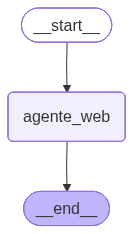

In [58]:
# forma de visualizar o grafo
# app.get_graph() pega a estrutura do grafo compilado
#.draw_mermaid_png() gera uma imagem no formato Mermaid (uma sintaxe popular para desenhar diagramas de fluxo)
# Image(...) exibe essa imagem dentro do notebook.

from IPython.display import Image, display
Image(app.get_graph().draw_mermaid_png())


In [59]:
# Gera uma função de agente supervisor que recebe as duas respostas (da internet e cientifica) e junta elas em uma resposta final
def supervisor_node(state: AgentState) -> dict:
  """
  Combina os resultados da web e de agentes científicos e formata a resposta final.

  Args:
      state: (AgentState): O estado atual do agewnte, contendo web_answer e scientific_answer.

  Returns:
      dict: Um dicionário contendo a resposta final combinada e formatada.
  """

  web_results = state.get("web_answer", "Não foi realizada pesquisa na Web.")
  scientific_results = state.get("scientific_answer", "Não foi realizada pesquisa científica.")

  final_answer = "## Resultados de pesquisa combinados\n\n"
  final_answer += "### Resultados da pesquisa na Web\n"
  final_answer += web_results
  final_answer += "\n\n### Resultados de Artigos Científicos\n"
  final_answer += scientific_results

  return {"final_answer": final_answer}

In [60]:
workflow = StateGraph(AgentState)
workflow.add_node('web_search', funcao_agente_web)
workflow.add_node('scientific_search', funcao_agente_cientifico)
workflow.add_node('supervisor', supervisor_node)

workflow.add_edge(START, 'web_search')
workflow.add_edge('web_search', 'scientific_search')
workflow.add_edge('scientific_search', 'supervisor')
workflow.add_edge('supervisor', END)

app = workflow.compile()

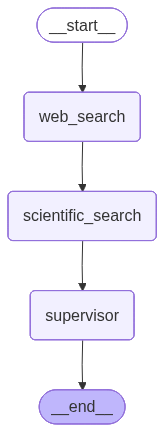

In [61]:
Image(app.get_graph().draw_mermaid_png())

In [62]:
resultado = app.invoke({"user_query": "AI impact in agriculture"})
print(resultado['final_answer'])

/tmp/ipykernel_3043/2824702100.py:23: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agente_web = create_react_agent(model=llm, tools=tools, prompt = system_prompt)


TIPO: <class 'str'>
CONTEUDO: Artificial Intelligence (AI) is transforming agriculture from a practice based on experience and intuition into a data-driven, precision-oriented industry. By integrating AI, farmers can optimize their operations, reduce waste, and increase yields while simultaneously addressing environmental challenges.

Here are the key areas where AI is making a significant impact on agriculture:

### 1. Productivity and Yield Improvement
AI helps farmers maximize output from the same amount of land. By using **predictive analytics**, AI models can analyze weather patterns, soil conditions, and historical crop data to provide specific recommendations:
*   **What and when to plant:** Systems advise on the optimal crop varieties and timing for sowing based on local conditions.
*   **Harvesting optimization:** AI tools analyze crop maturity to identify the exact window for harvesting, ensuring the highest quality and yield.

### 2. Precision Agriculture (Resource Efficienc

/tmp/ipykernel_3043/3099152979.py:26: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agente_cientifico = create_react_agent(model=llm, tools=tool_cientifica, prompt = system_prompt)


## Resultados de pesquisa combinados

### Resultados da pesquisa na Web
Artificial Intelligence (AI) is transforming agriculture from a practice based on experience and intuition into a data-driven, precision-oriented industry. By integrating AI, farmers can optimize their operations, reduce waste, and increase yields while simultaneously addressing environmental challenges.

Here are the key areas where AI is making a significant impact on agriculture:

### 1. Productivity and Yield Improvement
AI helps farmers maximize output from the same amount of land. By using **predictive analytics**, AI models can analyze weather patterns, soil conditions, and historical crop data to provide specific recommendations:
*   **What and when to plant:** Systems advise on the optimal crop varieties and timing for sowing based on local conditions.
*   **Harvesting optimization:** AI tools analyze crop maturity to identify the exact window for harvesting, ensuring the highest quality and yield.

### 2.

In [73]:
# Gera um agente roteador que decide qual dos dois agentes especialistas em busca vai ser ativado de acordo com a chamada do usuário
def router_agent(state: AgentState) -> dict:
  """
  Agente roteador que decide qual ferramenta usar (busca web ou busca científica)
  com base na pergunta do usuário, usando um agente ReAct interno.
  """
  # Define the prompt for the internal ReAct agent
  router_prompt = """
  Você é um agente roteador. Sua tarefa é decidir qual o agente é mais apropriado
  para responder à pergunta do usuário.

  Pergunta do usuário: {user_query}

  Você pode escolher entre as seguintes opções:
  - web_search: Use esta opção se a pergunta do usuário parecer exigir uma busca geral na web.
  - scientific_search: Use esta opção se a pergunta do usuário parecer exigir a busca por artigos científicos (por exemplo, no arXiv).

  Responda APENAS com o nome da opção escolhida (web_search ou scientific_search).
  """

  router_agent_instance = create_react_agent(
    model = llm,
    tools = [],
    prompt = router_prompt
  )

  response = router_agent_instance.invoke({"messages": [("user", state["user_query"])]})

  decision =  extrair_texto(response['messages'][-1].content).strip().lower()

  if 'web_search' in decision:
    return {'router_decision': 'web_search'}
  elif 'scientific_search' in decision:
    return {'router_decision': 'scientific_search'}
  else:
    return {'router_decision': 'web_search'}

In [74]:
workflow = StateGraph(AgentState)

workflow.add_node("router", router_agent)
workflow.add_node('web_search', funcao_agente_web)
workflow.add_node('scientific_search', funcao_agente_cientifico)
workflow.add_node('supervisor', supervisor_node)

workflow.add_edge(START, 'router')
# aresta condicional com função que lê o estado e devolve uma string. O fluxo segue o nó que corresponde à string devolvida pela função
workflow.add_conditional_edges(
    'router',
    lambda state: state['router_decision'],
    {
        'web_search': 'web_search',
        'scientific_search': 'scientific_search'
    }
)
workflow.add_edge('web_search', 'supervisor')
workflow.add_edge('scientific_search', 'supervisor')
workflow.add_edge('supervisor', END)

app = workflow.compile()

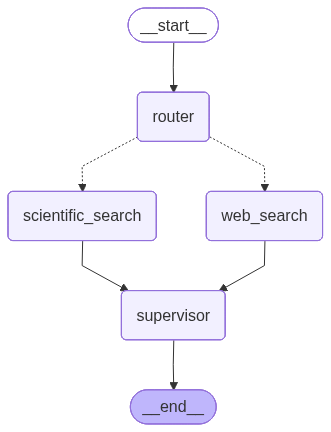

In [75]:
Image(app.get_graph().draw_mermaid_png())

In [ ]:
import gradio as gr

def run_graph(user_query):
  """
  Executa o LangGraph com a query do usuário e retorna a resposta final
  """

  result = app.invoke({"user_query": user_query})
  return result['final_answer']


iface = gr.Interface(
    fn = run_graph,
    inputs = gr.Textbox(label = 'Digite sua pergunta'),
    outputs = gr.Markdown(label = 'Resposta final: '),
    title = 'Agente de pesquisa com LangGraph',
    description = 'Faça uma pergunta e obtenha uma resposta com fontes web ou fontes científicas'
)

iface.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://14301013f798f8f413.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/tmp/ipykernel_3043/2821250691.py:21: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  router_agent_instance = create_react_agent(
/tmp/ipykernel_3043/2824702100.py:23: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agente_web = create_react_agent(model=llm, tools=tools, prompt = system_prompt)


TIPO: <class 'str'>
CONTEUDO: Determining the "smallest" animal depends on how you define the category, as there is a distinction between microscopic organisms and vertebrates.

*   **Overall Smallest Animal:** The title for the smallest animal on Earth is widely attributed to **myxozoans**. These are microscopic, parasitic invertebrates related to jellyfish. Many myxozoan species consist of only a single cell when they reach maturity, making them smaller than any other multicellular animal.

*   **Smallest Vertebrate:** If you are referring specifically to vertebrates (animals with a backbone), the title currently belongs to a frog called ***Brachycephalus pulex***. It is exceptionally tiny, often measuring less than 10 millimeters in length.

*   **Smallest Mammals:** Among mammals, the title is shared by the **Etruscan shrew** (*Suncus etruscus*) and the **bumblebee bat** (*Craseonycteris thonglongyai*), which are both incredibly small but significantly larger than the microscopic m